In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

In [20]:
df = pd.read_csv("Dataset_A.csv")

target_cols = ['r1','r2','r3','D1','D2','D3']

X = df.drop(columns=target_cols)
y = df[target_cols]

# Numeric-only features
numeric_cols = X.select_dtypes(include=[np.number]).columns
X = X[numeric_cols]

In [21]:
# 2) Handle Missing Values
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [22]:
# 3) Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.20, random_state=42
)

In [23]:
xgb = XGBRegressor(
    n_estimators=600,    
    learning_rate=0.03,  
    max_depth=8,         
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

model = MultiOutputRegressor(xgb)
print("Training XGBoost...")
model.fit(X_train, y_train)
print("Training Complete!")

Training XGBoost...
Training Complete!


In [24]:
y_pred = model.predict(X_test)

In [25]:
# 6) Evaluation Metrics
results = []
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    results.append([col, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Parameter", "RMSE", "MAE", "R2"])
print("\n===== XGBoost Evaluation =====")
print(results_df)

# ---- OVERALL R² (Flattened) ----
overall_r2 = r2_score(y_test.values.flatten(), y_pred.flatten())
print(f"\nOverall R²: {overall_r2*100:.2f}%")


===== XGBoost Evaluation =====
  Parameter      RMSE       MAE        R2
0        r1  0.975513  0.764787  0.269775
1        r2  1.279323  1.019985  0.203748
2        r3  1.479013  1.237475 -0.084027
3        D1  0.003307  0.002102  0.782544
4        D2  0.002005  0.001376  0.921747
5        D3  0.004257  0.003358  0.260753

Overall R²: 97.22%


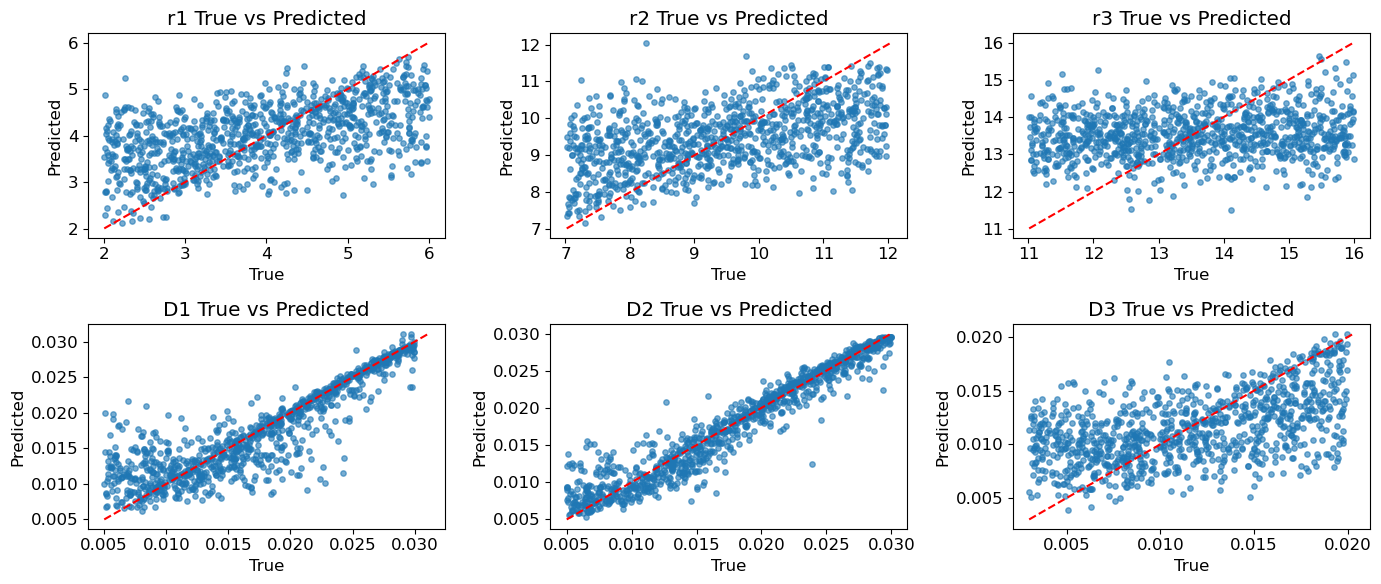

In [26]:
plt.figure(figsize=(14,6))

for i, col in enumerate(target_cols):
    plt.subplot(2, 3, i+1)
    
    actual = y_test.iloc[:, i]
    pred   = y_pred[:, i]
    
    mn = min(actual.min(), pred.min())
    mx = max(actual.max(), pred.max())
    
    plt.scatter(actual, pred, s=15, alpha=0.6)
    plt.plot([mn, mx], [mn, mx], 'r--')
    
    plt.title(f"{col} True vs Predicted")
    plt.xlabel("True")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

In [27]:
np.save("true_inverse_A_xgb.npy", y_test)
np.save("pred_inverse_A_xgb.npy", y_pred)